# MSDS Curriculum × Job Market — Matching Analysis
**CU Boulder Master of Science in Data Science**

This notebook computes compatibility scores between the 130 MSDS courses and data science
job roles scraped from LinkedIn (100 postings). Courses are split throughout into
**Core** (Sections 1–3) and **Elective** (Section 4) to show where the required curriculum
aligns with market demand versus where elective choices fill the gap.

Sections:
1. Setup & Imports
2. Load Data
3. Text Preprocessing & TF-IDF Vectorization
4. Compatibility Score Matrix
5. Job Role → Course Matching
6. Course → Job Role Matching
7. Keyword Gap Analysis
8. Summary & Insights


## 1  Setup & Imports

In [1]:
import json, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Palette ──────────────────────────────────────────────────────────────────
CU_GOLD  = '#CFB87C'
CU_NAVY  = '#0D1526'

# Four-way colour scheme: (source_type, course_category) → hex
CAT_COLORS = {
    ('Online (DTSA)', 'Core'):     '#B8924A',   # deep gold
    ('Online (DTSA)', 'Elective'): '#E8CB88',   # light gold
    ('On-Campus',     'Core'):     '#1F4F8F',   # deep blue
    ('On-Campus',     'Elective'): '#7AAED4',   # light blue
}

CAT_LABELS = {
    ('Online (DTSA)', 'Core'):     'Online – Core',
    ('Online (DTSA)', 'Elective'): 'Online – Elective',
    ('On-Campus',     'Core'):     'On-Campus – Core',
    ('On-Campus',     'Elective'): 'On-Campus – Elective',
}

ROLE_PALETTE = px.colors.qualitative.Bold


## 2  Load Data

In [2]:
with open('cu_boulder_msds_courses.json') as f:
    courses_raw = json.load(f)

jobs_files = glob.glob('linkedin_ds_jobs_*.json')
assert jobs_files, "No jobs JSON found — run scrape_linkedin_jobs.py first"
with open(sorted(jobs_files)[-1]) as f:
    jobs_raw = json.load(f)

print(f"Jobs file : {sorted(jobs_files)[-1]}")
print(f"Scraped at: {jobs_raw['metadata']['scraped_at']}")


Jobs file : linkedin_ds_jobs_20260629_142606.json
Scraped at: 2026-06-29T14:26:06.902188+00:00


In [3]:
# ── Courses DataFrame ──────────────────────────────────────────────────────────
all_courses = (courses_raw['courses']['online_dtsa'] +
               courses_raw['courses']['on_campus_electives'])

courses_df = pd.DataFrame(all_courses)
courses_df['description']  = courses_df['description'].fillna('').astype(str)
courses_df['course_title'] = courses_df['course_title'].fillna('').astype(str)

courses_df['source_type'] = courses_df['course_code'].apply(
    lambda x: 'Online (DTSA)' if str(x).startswith('DTSA') else 'On-Campus'
)

def _to_category(section: str) -> str:
    """Section 4 = Elective; Sections 1-3 = Core."""
    return 'Elective' if 'section 4' in str(section).lower() else 'Core'

courses_df['course_category'] = courses_df['program_section'].apply(_to_category)

# Combined key used for colour lookups
courses_df['cat_key'] = list(zip(courses_df['source_type'], courses_df['course_category']))

print(f"Total courses : {len(courses_df)}")
print()
print(courses_df.groupby(['source_type', 'course_category']).size()
      .rename('count').reset_index().to_string(index=False))


Total courses : 130

  source_type course_category  count
    On-Campus            Core      8
    On-Campus        Elective     49
Online (DTSA)            Core     24
Online (DTSA)        Elective     49


In [4]:
# ── Jobs DataFrame ─────────────────────────────────────────────────────────────
jobs_df = pd.DataFrame(jobs_raw['jobs'])
jobs_df['description'] = jobs_df['description'].fillna('').astype(str)

print(f"Total jobs : {len(jobs_df)}")
print()
print(jobs_df['search_keyword'].value_counts().rename('count').to_frame().to_string())


Total jobs : 100

                           count
search_keyword                  
Data Scientist                17
AI Engineer                   17
ML Engineer                   17
MLOps Engineer                17
Machine Learning Engineer     17
Applied Scientist             15


## 3  Text Preprocessing & TF-IDF Vectorization

In [5]:
_STOP = {
    'experience', 'work', 'working', 'team', 'skills', 'ability', 'strong',
    'including', 'required', 'preferred', 'related', 'across', 'within',
    'using', 'help', 'also', 'role', 'opportunity', 'position', 'job',
    'company', 'years', 'knowledge', 'understanding', 'excellent',
}

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s\-]', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join(t for t in text.split() if t not in _STOP and len(t) > 2)

# Aggregate jobs by role
role_texts = {
    role: ' '.join(grp['description'].tolist())
    for role, grp in jobs_df.groupby('search_keyword')
}
role_labels = sorted(role_texts.keys())
n_roles     = len(role_labels)

# Course text: title repeated for extra weight + description
courses_df['full_text'] = (
    courses_df['course_title'].apply(lambda t: (t + ' ') * 4) +
    courses_df['description']
)
course_texts   = [preprocess(t) for t in courses_df['full_text']]
role_text_pp   = [preprocess(role_texts[r]) for r in role_labels]

print(f"Roles : {role_labels}")
print(f"Courses with non-empty text: {sum(1 for t in course_texts if len(t) > 10)}/{len(course_texts)}")


Roles : ['AI Engineer', 'Applied Scientist', 'Data Scientist', 'ML Engineer', 'MLOps Engineer', 'Machine Learning Engineer']
Courses with non-empty text: 130/130


In [6]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=12_000,
    stop_words='english',
    min_df=1,
    sublinear_tf=True,
)

all_texts  = course_texts + role_text_pp
tfidf_all  = vectorizer.fit_transform(all_texts)

course_vecs = tfidf_all[:len(courses_df)]
role_vecs   = tfidf_all[len(courses_df):]

raw_sim = cosine_similarity(course_vecs, role_vecs)

# Scale to 0–100 then min-max normalise per role
scores = raw_sim * 100
for col_i in range(scores.shape[1]):
    col = scores[:, col_i]
    lo, hi = col.min(), col.max()
    if hi > lo:
        scores[:, col_i] = (col - lo) / (hi - lo) * 100

sim_df = pd.DataFrame(scores,
                      index=courses_df['course_code'].tolist(),
                      columns=role_labels)

# Attach scores back to courses_df
courses_df['best_role']  = sim_df.idxmax(axis=1).values
courses_df['best_score'] = sim_df.max(axis=1).values
courses_df['mean_score'] = sim_df.mean(axis=1).values
courses_df['coverage']   = (sim_df > 40).sum(axis=1).values
for role in role_labels:
    courses_df[role] = sim_df[role].values

print("Compatibility matrix:", sim_df.shape)
print("\nMean score by category:")
print(courses_df.groupby(['source_type', 'course_category'])['mean_score']
      .mean().round(1).to_string())


Compatibility matrix: (130, 6)

Mean score by category:
source_type    course_category
On-Campus      Core               47.7
               Elective           49.7
Online (DTSA)  Core               38.0
               Elective           51.1


## 4  Compatibility Score Matrix

Scores (0–100) are TF-IDF cosine similarity normalised per role.
Rows are sorted **Core first, then Elective** within each block;
a horizontal divider marks the boundary.


In [7]:
# ── Sort rows: Core first, Elective second; within each block by max score desc ──
cat_order = courses_df[['course_code', 'course_category', 'source_type']].copy()
cat_order['max_score'] = sim_df.max(axis=1).values
cat_order['sort_key']  = cat_order['course_category'].map({'Core': 0, 'Elective': 1})
cat_order = cat_order.sort_values(['sort_key', 'max_score'], ascending=[True, False])

sorted_codes    = cat_order['course_code'].tolist()
sim_sorted      = sim_df.loc[sorted_codes]
n_core_total    = (cat_order['course_category'] == 'Core').sum()

title_map = courses_df.set_index('course_code')['course_title'].to_dict()
stype_map = courses_df.set_index('course_code')['source_type'].to_dict()
cat_map   = courses_df.set_index('course_code')['course_category'].to_dict()
catkey_map= courses_df.set_index('course_code')['cat_key'].to_dict()

print(f"Core rows  : {n_core_total}")
print(f"Elective rows: {len(sorted_codes) - n_core_total}")


Core rows  : 32
Elective rows: 98


In [8]:
# ── Interactive full matrix (Plotly) — coloured marker column on left ──
hover_labels = [
    f"{c}  {title_map.get(c,'')[:50]}<br>"
    f"<i>{stype_map.get(c,'')} · {cat_map.get(c,'')}</i>"
    for c in sim_sorted.index
]

# Build a colour column (first column = category indicator)
cat_indicator = [1 if cat_map.get(c) == 'Core' else 0 for c in sim_sorted.index]

fig = go.Figure()
fig.add_trace(go.Heatmap(
    z          = sim_sorted.values,
    x          = role_labels,
    y          = hover_labels,
    colorscale = 'YlOrRd',
    colorbar   = dict(title='Score', thickness=14, len=0.5, x=1.02),
    zmin=0, zmax=100,
    hovertemplate='<b>%{y}</b><br>Role: %{x}<br>Score: %{z:.1f}<extra></extra>',
))
# Divider line between Core and Elective
fig.add_shape(type='line',
    x0=-0.5, x1=n_roles - 0.5,
    y0=n_core_total - 0.5, y1=n_core_total - 0.5,
    line=dict(color='#2D5F9E', width=3, dash='dot'),
)
fig.add_annotation(
    x=n_roles - 0.5, y=n_core_total - 0.5,
    text='← Core above  |  Elective below →',
    showarrow=False, xanchor='right',
    font=dict(size=10, color='#2D5F9E'),
    bgcolor='white', bordercolor='#2D5F9E', borderwidth=1,
)
fig.update_layout(
    title=dict(text='Full Course × Job Role Compatibility Matrix (Core | Elective)', font_size=14),
    height=max(700, len(sim_sorted) * 13 + 140),
    margin=dict(l=380, r=60, t=70, b=80),
    xaxis=dict(side='top', tickangle=-30),
    yaxis=dict(tickfont_size=9, autorange='reversed'),
    paper_bgcolor='#FAFBFD', plot_bgcolor='#FAFBFD',
)
fig.show()


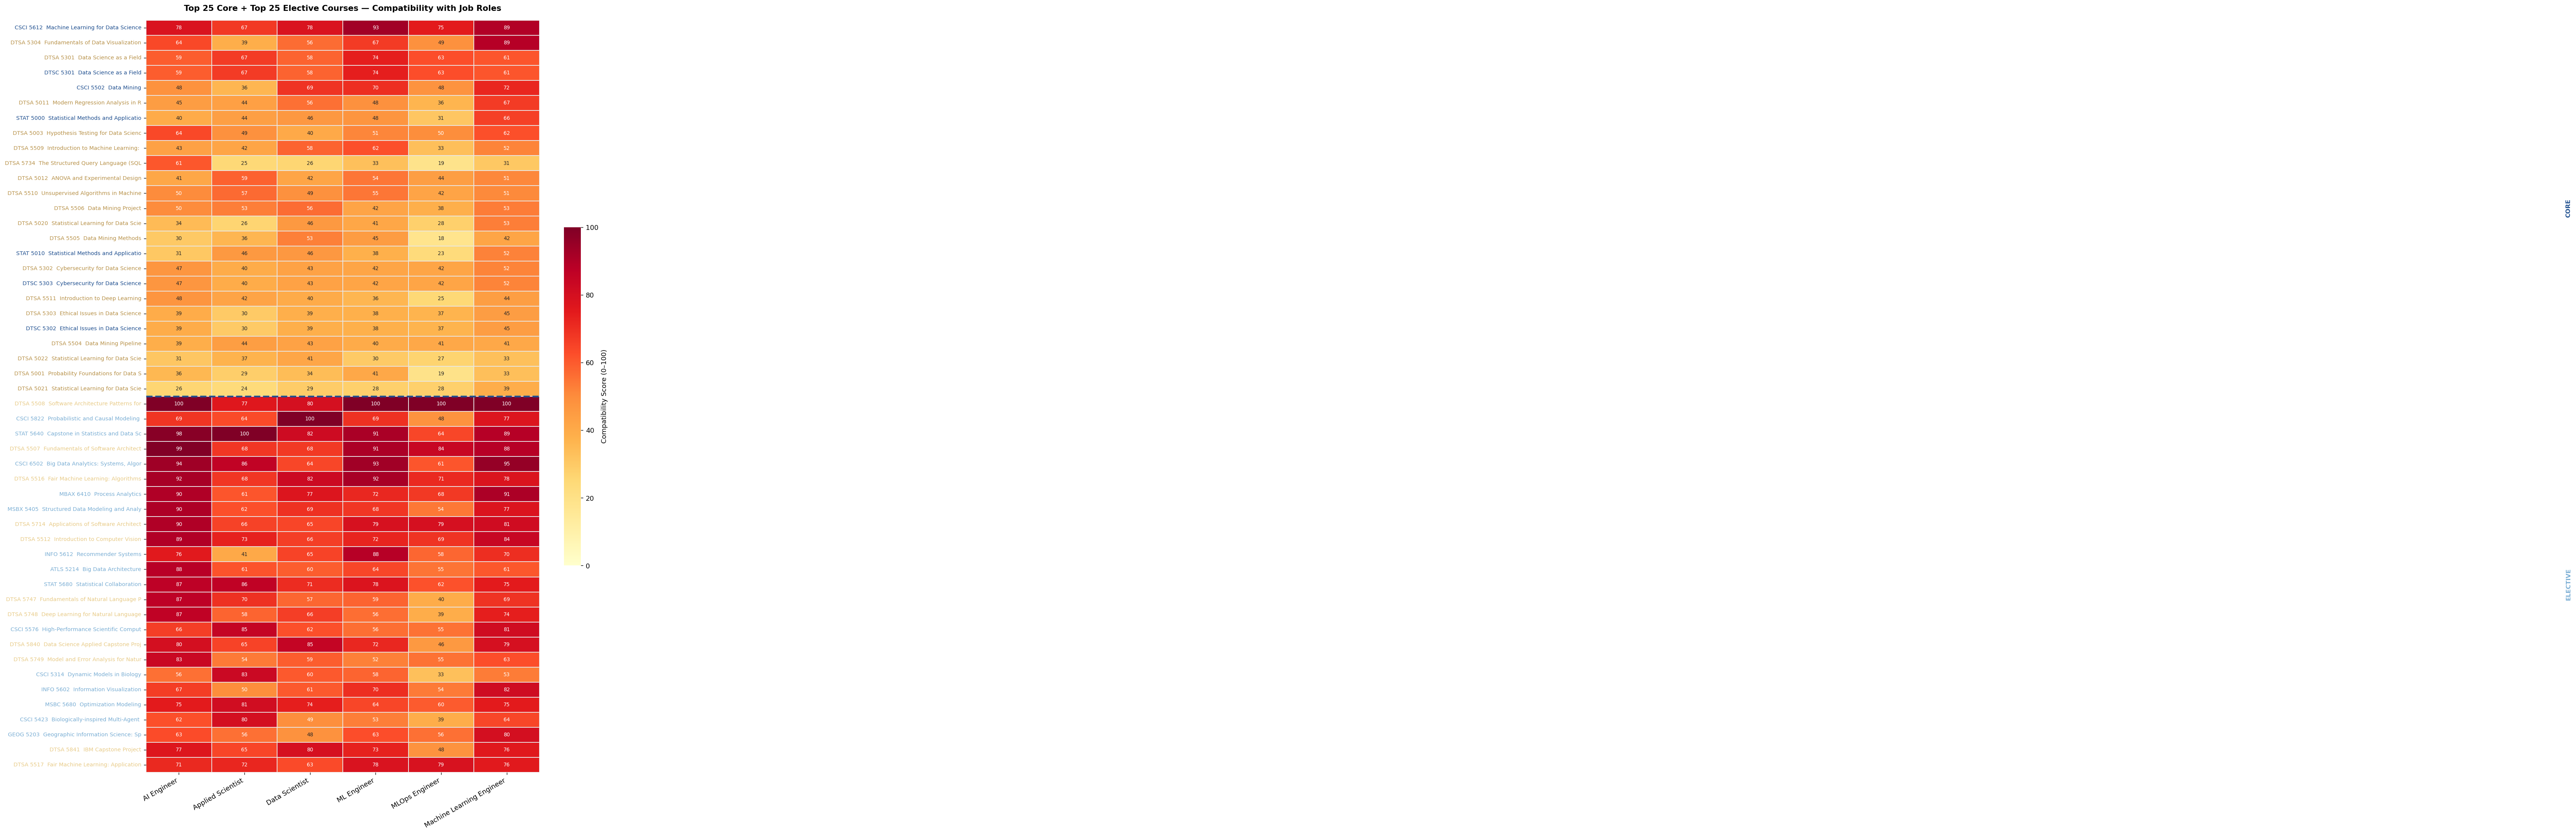

Saved → compatibility_top50.png


In [9]:
# ── Static heatmap: top 25 Core + top 25 Elective ────────────────────────────
core_top    = cat_order[cat_order['course_category'] == 'Core']['course_code'].head(25).tolist()
elec_top    = cat_order[cat_order['course_category'] == 'Elective']['course_code'].head(25).tolist()
plot_codes  = core_top + elec_top
plot_df     = sim_df.loc[plot_codes]
n_core_plot = len(core_top)

ylabels = [
    f"{c}  {title_map.get(c,'')[:34]}"
    for c in plot_codes
]

fig, ax = plt.subplots(figsize=(13, 20))
sns.heatmap(
    plot_df,
    ax=ax,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    vmin=0, vmax=100,
    linewidths=0.25, linecolor='#e8e8e8',
    yticklabels=ylabels,
    cbar_kws=dict(label='Compatibility Score (0–100)', shrink=0.45),
    annot_kws=dict(size=7.5),
)

# Horizontal divider between Core and Elective blocks
ax.axhline(n_core_plot, color='#1F4F8F', linewidth=2.5, linestyle='--')

# Block labels in the right margin
mid_core = n_core_plot / 2
mid_elec = n_core_plot + (len(elec_top) / 2)
for y_pos, label, color in [
    (mid_core, 'CORE',     '#1F4F8F'),
    (mid_elec, 'ELECTIVE', '#7AAED4'),
]:
    ax.text(n_roles + 0.15, y_pos, label,
            va='center', ha='left', fontsize=9, fontweight='bold',
            color=color, rotation=90,
            transform=ax.get_yaxis_transform())

# Colour the y-tick labels by category
ytick_labels = ax.get_yticklabels()
for i, lbl in enumerate(ytick_labels):
    cat   = 'Core' if i < n_core_plot else 'Elective'
    stype = 'Online (DTSA)' if plot_codes[i].startswith('DTSA') else 'On-Campus'
    lbl.set_color(CAT_COLORS[(stype, cat)])
    lbl.set_fontsize(8)

ax.set_xticklabels(role_labels, rotation=30, ha='right', fontsize=10)
ax.set_title('Top 25 Core + Top 25 Elective Courses — Compatibility with Job Roles',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel(''); ax.set_ylabel('')

plt.tight_layout()
plt.savefig('compatibility_top50.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → compatibility_top50.png")


## 5  Job Role → Course Matching

Top 12 courses per role. Bars are coloured by **source type × category**:

| Colour | Meaning |
|---|---|
| Deep gold | Online DTSA — Core |
| Light gold | Online DTSA — Elective |
| Deep blue | On-Campus — Core |
| Light blue | On-Campus — Elective |

A dashed divider separates Core from Elective within each chart.


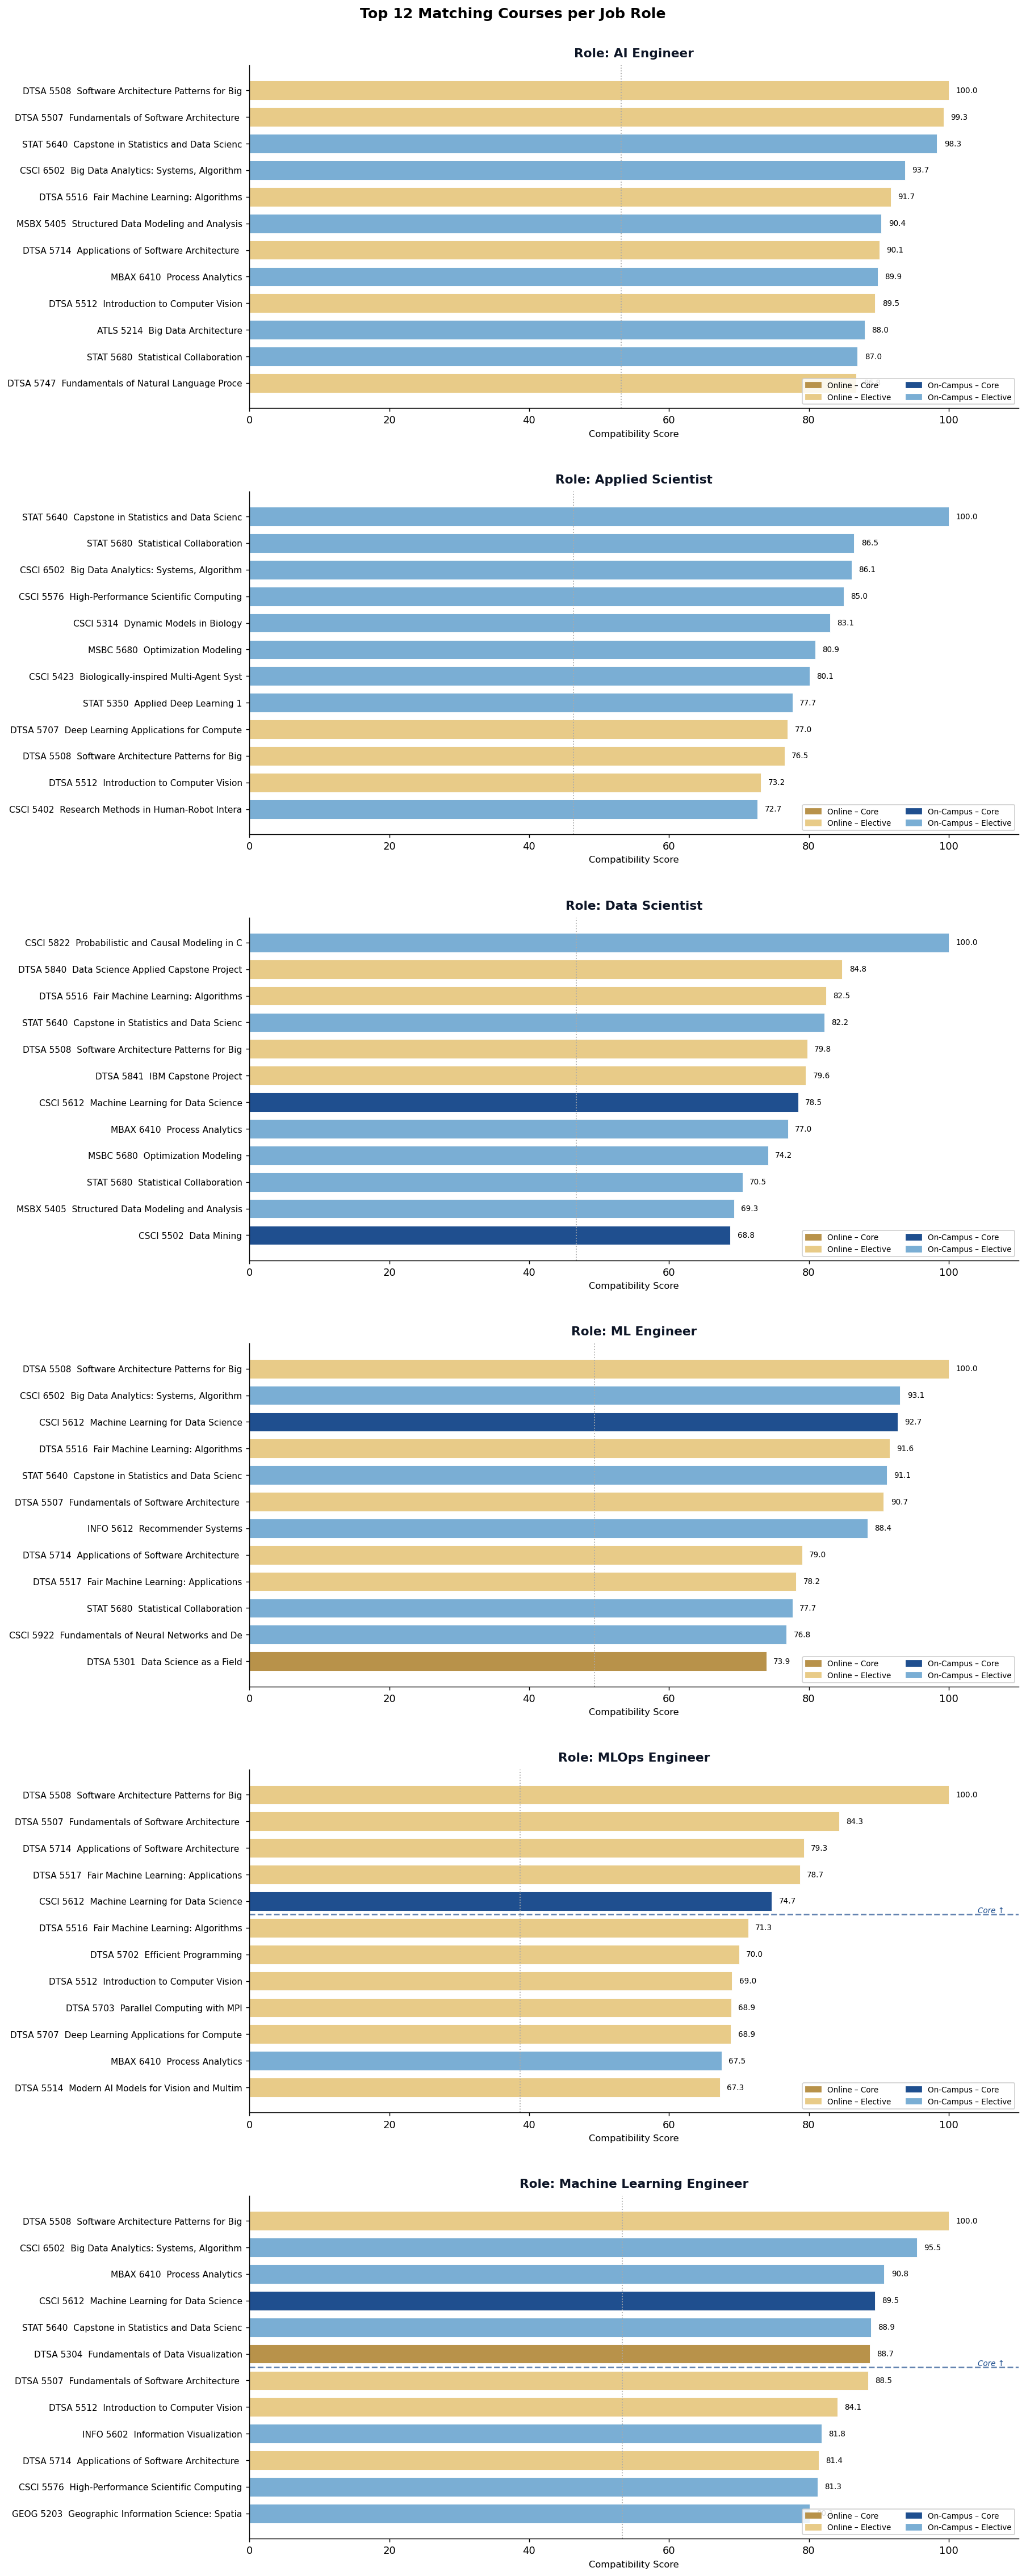

Saved → role_to_course.png


In [10]:
TOP_N = 12

legend_handles = [
    mpatches.Patch(color=CAT_COLORS[k], label=CAT_LABELS[k])
    for k in [('Online (DTSA)', 'Core'), ('Online (DTSA)', 'Elective'),
              ('On-Campus', 'Core'),     ('On-Campus', 'Elective')]
]

fig, axes = plt.subplots(n_roles, 1, figsize=(14, n_roles * 5.8))
if n_roles == 1:
    axes = [axes]

for ax, role in zip(axes, role_labels):
    top = sim_df[role].nlargest(TOP_N).sort_values()   # ascending for barh
    colors = [CAT_COLORS[catkey_map.get(c, ('On-Campus', 'Elective'))] for c in top.index]
    labels = [f"{c}  {title_map.get(c,'')[:38]}" for c in top.index]

    bars = ax.barh(range(len(top)), top.values, color=colors,
                   edgecolor='white', linewidth=0.5, height=0.72)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.set_xlim(0, 110)
    ax.set_xlabel('Compatibility Score', fontsize=9)
    ax.set_title(f'Role: {role}', fontsize=12, fontweight='bold',
                 color=CU_NAVY, pad=8)

    # Score labels
    for bar, val in zip(bars, top.values):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=7.5)

    # Divider between Elective and Core (bars sorted ascending, so find boundary)
    codes_asc = list(top.index)
    core_indices = [i for i, c in enumerate(codes_asc) if cat_map.get(c) == 'Core']
    if core_indices and min(core_indices) > 0:
        boundary = min(core_indices) - 0.5
        ax.axhline(boundary, color='#1F4F8F', linewidth=1.5,
                   linestyle='--', alpha=0.7)
        ax.text(108, boundary, 'Core ↑', ha='right', va='bottom',
                fontsize=7.5, color='#1F4F8F', style='italic')

    # Mean score reference
    mean_val = sim_df[role].mean()
    ax.axvline(mean_val, color='#aaa', linestyle=':', linewidth=1,
               label=f'All-course mean ({mean_val:.1f})')

    ax.legend(handles=legend_handles, fontsize=7.5,
              loc='lower right', ncol=2, framealpha=0.85)

plt.suptitle('Top 12 Matching Courses per Job Role', fontsize=14,
             fontweight='bold', y=1.002)
plt.tight_layout(h_pad=3.5)
plt.savefig('role_to_course.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → role_to_course.png")


In [11]:
# ── Pivot table: top 5 per role with category column ─────────────────────────
rows = []
for role in role_labels:
    for rank, (code, score) in enumerate(sim_df[role].nlargest(5).items(), 1):
        rows.append({
            'Role': role,
            'Rank': rank,
            'Code': code,
            'Title': title_map.get(code, '')[:55],
            'Type': stype_map.get(code, ''),
            'Category': cat_map.get(code, ''),
            'Score': round(score, 1),
        })

top5_df = pd.DataFrame(rows)

def _highlight_cat(val):
    return ('background-color: #FFF3CC' if val == 'Core'
            else 'background-color: #E8F0FC')

top5_df.style \
    .applymap(_highlight_cat, subset=['Category']) \
    .background_gradient(subset=['Score'], cmap='YlOrRd') \
    .set_caption('Top 5 Courses per Job Role (yellow = Core, blue = Elective)')


,Role,Rank,Code,Title,Type,Category,Score
0,AI Engineer,1,DTSA 5508,Software Architecture Patterns for Big Data,Online (DTSA),Elective,100.000000
1,AI Engineer,2,DTSA 5507,Fundamentals of Software Architecture for Big Data,Online (DTSA),Elective,99.300000
2,AI Engineer,3,STAT 5640,Capstone in Statistics and Data Science,On-Campus,Elective,98.300000
3,AI Engineer,4,CSCI 6502,"Big Data Analytics: Systems, Algorithms, and Applicatio",On-Campus,Elective,93.700000
4,AI Engineer,5,DTSA 5516,Fair Machine Learning: Algorithms,Online (DTSA),Elective,91.700000
5,Applied Scientist,1,STAT 5640,Capstone in Statistics and Data Science,On-Campus,Elective,100.000000
6,Applied Scientist,2,STAT 5680,Statistical Collaboration,On-Campus,Elective,86.500000
7,Applied Scientist,3,CSCI 6502,"Big Data Analytics: Systems, Algorithms, and Applicatio",On-Campus,Elective,86.100000
8,Applied Scientist,4,CSCI 5576,High-Performance Scientific Computing,On-Campus,Elective,85.000000
9,Applied Scientist,5,CSCI 5314,Dynamic Models in Biology,On-Campus,Elective,83.100000


## 6  Course → Job Role Matching

Full ranked table and radar charts comparing average compatibility across
course types (Online/On-Campus) **and** curriculum position (Core/Elective).


In [12]:
display_cols = (['course_code', 'course_title', 'source_type', 'course_category',
                 'best_role', 'best_score', 'mean_score', 'coverage']
                + role_labels)

summary = (
    courses_df[display_cols]
    .sort_values('best_score', ascending=False)
    .reset_index(drop=True)
)
summary.index += 1
summary.columns = (['Code', 'Title', 'Type', 'Category', 'Best Role',
                    'Best Score', 'Avg Score', 'Roles>40']
                   + role_labels)

def _cat_bg(val):
    return ('background-color: #FFF3CC' if val == 'Core'
            else 'background-color: #E8F0FC')

summary.style \
    .applymap(_cat_bg, subset=['Category']) \
    .background_gradient(subset=['Best Score', 'Avg Score'] + role_labels, cmap='YlOrRd') \
    .format({c: '{:.1f}' for c in ['Best Score', 'Avg Score'] + role_labels}) \
    .set_caption('Course → Job Role Compatibility (Core=yellow, Elective=blue)')


,Code,Title,Type,Category,Best Role,Best Score,Avg Score,Roles>40,AI Engineer,Applied Scientist,Data Scientist,ML Engineer,MLOps Engineer,Machine Learning Engineer
1,CSCI 5822,Probabilistic and Causal Modeling in Computer Science,On-Campus,Elective,Data Scientist,100.0,71.1,6,68.7,63.5,100.0,69.4,47.7,77.1
2,STAT 5640,Capstone in Statistics and Data Science,On-Campus,Elective,Applied Scientist,100.0,87.5,6,98.3,100.0,82.2,91.1,64.4,88.9
3,DTSA 5508,Software Architecture Patterns for Big Data,Online (DTSA),Elective,AI Engineer,100.0,92.7,6,100.0,76.5,79.8,100.0,100.0,100.0
4,DTSA 5507,Fundamentals of Software Architecture for Big Data,Online (DTSA),Elective,AI Engineer,99.3,83.1,6,99.3,68.2,67.5,90.7,84.3,88.5
5,CSCI 6502,"Big Data Analytics: Systems, Algorithms, and Applications",On-Campus,Elective,Machine Learning Engineer,95.5,82.3,6,93.7,86.1,64.3,93.1,61.2,95.5
6,CSCI 5612,Machine Learning for Data Science,On-Campus,Core,ML Engineer,92.7,80.2,6,78.2,67.5,78.5,92.7,74.7,89.5
7,DTSA 5516,Fair Machine Learning: Algorithms,Online (DTSA),Elective,AI Engineer,91.7,80.5,6,91.7,68.3,82.5,91.6,71.3,77.8
8,MBAX 6410,Process Analytics,On-Campus,Elective,Machine Learning Engineer,90.8,76.3,6,89.9,61.2,77.0,71.7,67.5,90.8
9,MSBX 5405,Structured Data Modeling and Analysis,On-Campus,Elective,AI Engineer,90.4,70.3,6,90.4,62.4,69.3,68.2,54.0,77.4
10,DTSA 5714,Applications of Software Architecture for Big Data,Online (DTSA),Elective,AI Engineer,90.1,76.7,6,90.1,65.5,64.7,79.0,79.3,81.4


In [13]:
# ── Radar chart: 4 traces (2 source types × 2 categories) ────────────────────
groups = [
    ('Online (DTSA)', 'Core',     '#B8924A', 'solid'),
    ('Online (DTSA)', 'Elective', '#E8CB88', 'dot'),
    ('On-Campus',     'Core',     '#1F4F8F', 'solid'),
    ('On-Campus',     'Elective', '#7AAED4', 'dot'),
]

fig = go.Figure()
for stype, cat, color, dash in groups:
    mask  = (courses_df['source_type'] == stype) & (courses_df['course_category'] == cat)
    means = courses_df[mask][role_labels].mean()
    fig.add_trace(go.Scatterpolar(
        r     = means.tolist() + [means.iloc[0]],
        theta = role_labels + [role_labels[0]],
        name  = f'{stype} – {cat}',
        line  = dict(color=color, width=2.5, dash=dash),
        fill  = 'toself',
        fillcolor = color,
        opacity=0.18,
    ))

fig.update_layout(
    polar       = dict(radialaxis=dict(visible=True, range=[0, 85])),
    title       = 'Average Compatibility by Course Type & Category vs Job Role',
    showlegend  = True,
    legend      = dict(x=1.05, y=1),
    height      = 520,
)
fig.show()


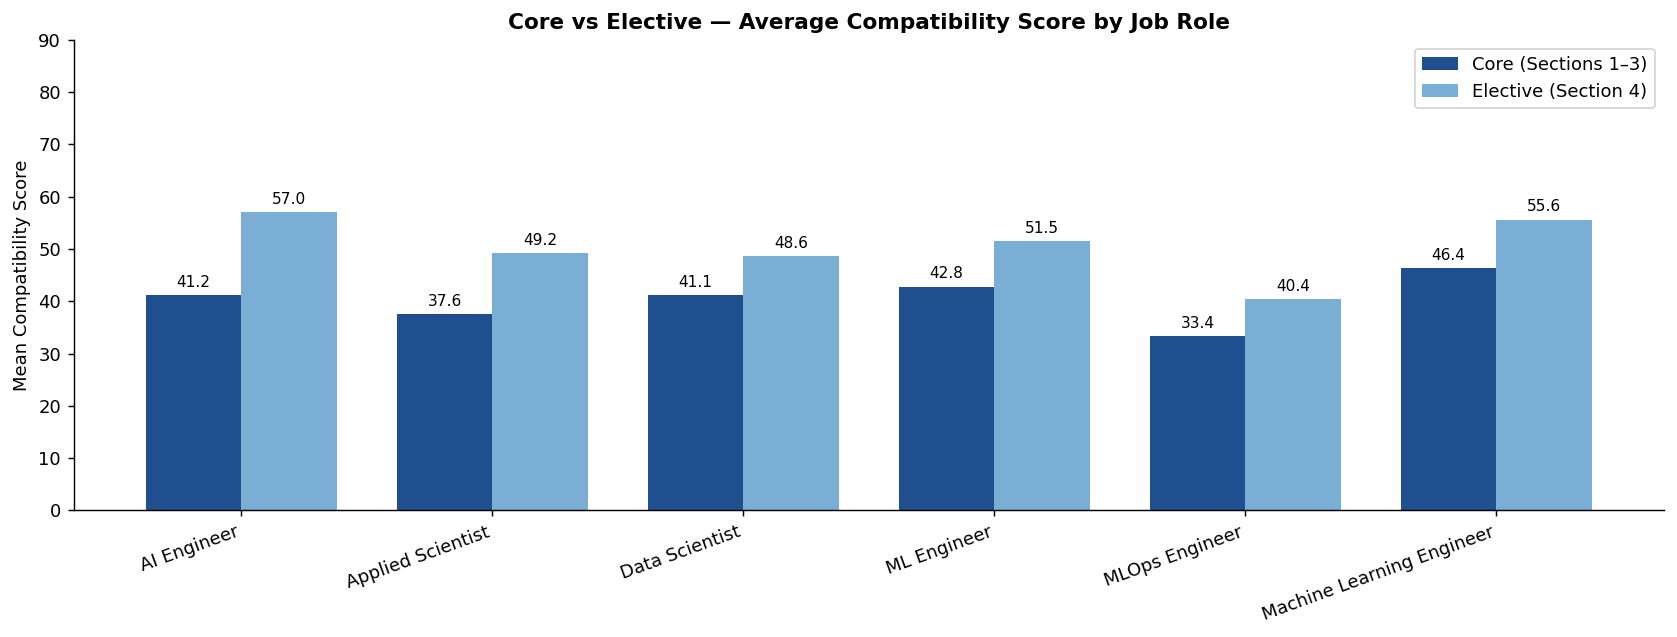

Saved → core_vs_elective_by_role.png


In [14]:
# ── Side-by-side bar: Core vs Elective mean score per role ────────────────────
core_means = courses_df[courses_df['course_category'] == 'Core'][role_labels].mean()
elec_means = courses_df[courses_df['course_category'] == 'Elective'][role_labels].mean()

x   = np.arange(n_roles)
w   = 0.38
fig, ax = plt.subplots(figsize=(13, 5))

b1 = ax.bar(x - w/2, core_means.values, w,
            color='#1F4F8F', label='Core (Sections 1–3)')
b2 = ax.bar(x + w/2, elec_means.values, w,
            color='#7AAED4', label='Elective (Section 4)')

ax.set_xticks(x)
ax.set_xticklabels(role_labels, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Mean Compatibility Score')
ax.set_title('Core vs Elective — Average Compatibility Score by Job Role',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 90)
ax.legend(fontsize=10)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.savefig('core_vs_elective_by_role.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → core_vs_elective_by_role.png")


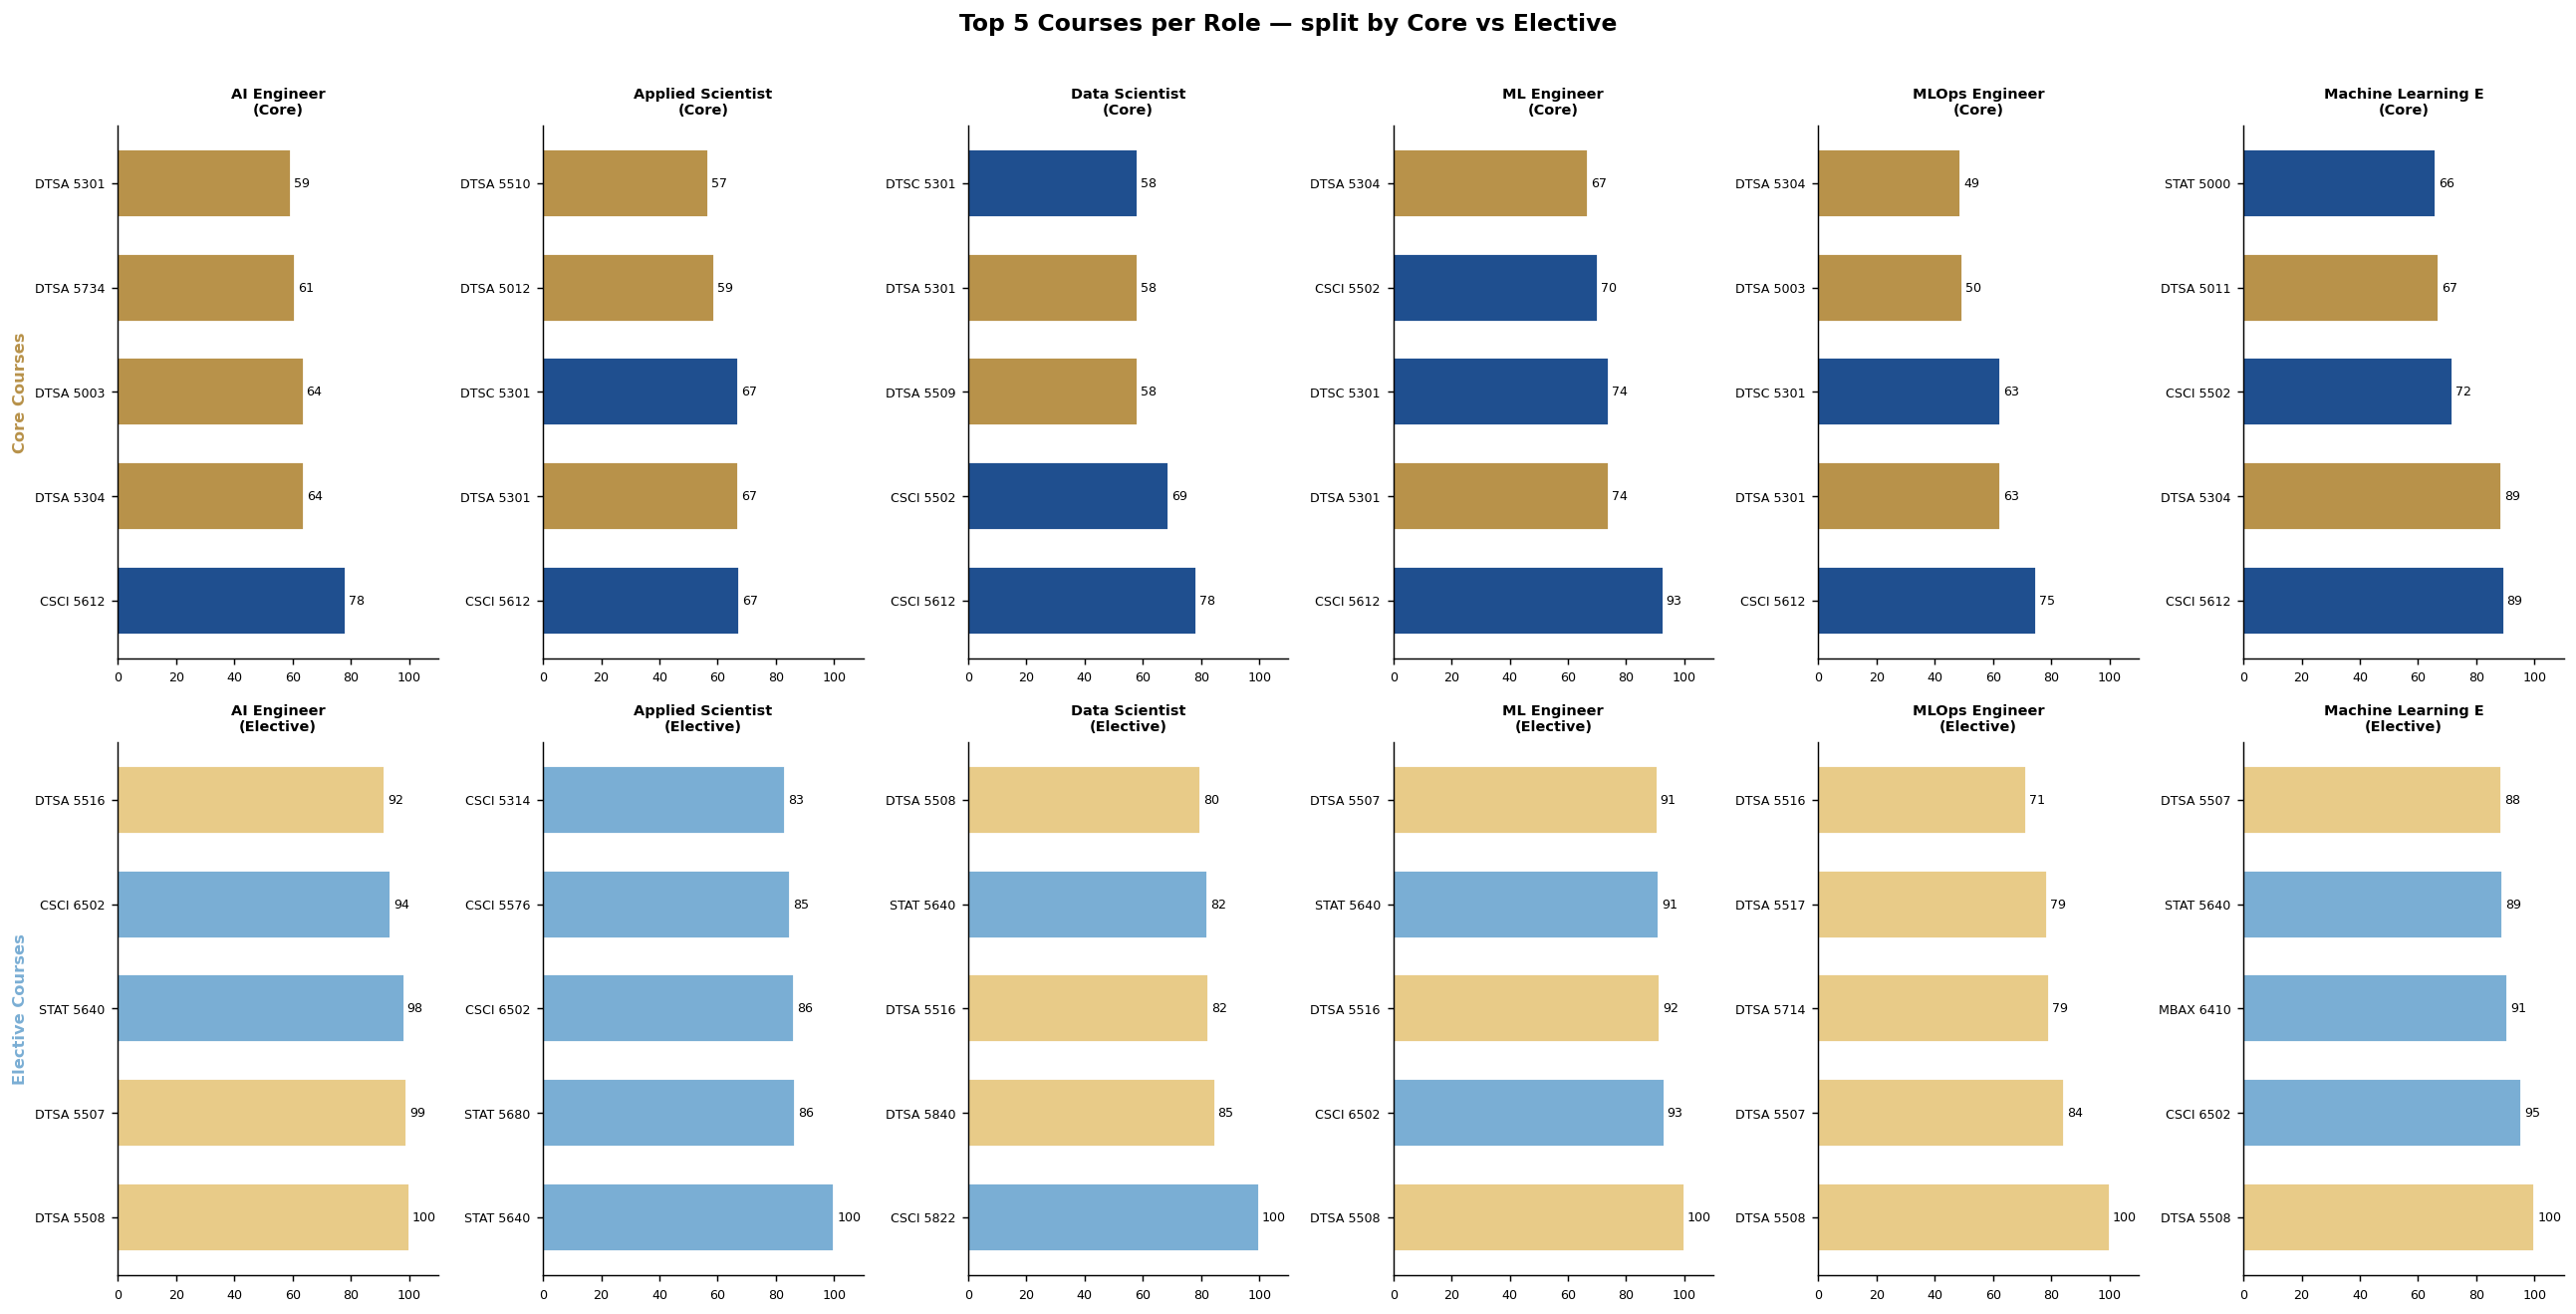

Saved → top5_online_vs_campus.png


In [15]:
# ── Top-5 online vs campus split by core/elective ─────────────────────────────
fig, axes = plt.subplots(2, n_roles, figsize=(20, 10),
                         sharex=False, sharey=False)
fig.suptitle('Top 5 Courses per Role — split by Core vs Elective',
             fontsize=13, fontweight='bold', y=1.01)

for col_i, role in enumerate(role_labels):
    for row_i, (cat, color, dtsa_c, camp_c) in enumerate([
        ('Core',     'Core Courses',     '#B8924A', '#1F4F8F'),
        ('Elective', 'Elective Courses', '#E8CB88', '#7AAED4'),
    ]):
        ax = axes[row_i][col_i]
        subset = courses_df[courses_df['course_category'] == cat]
        top5   = subset.nlargest(5, role)[['course_code', 'source_type', role]]

        colors = [dtsa_c if t == 'Online (DTSA)' else camp_c
                  for t in top5['source_type']]
        labels = top5['course_code'].tolist()

        ax.barh(labels, top5[role].values, color=colors,
                edgecolor='white', height=0.65)
        ax.set_xlim(0, 110)
        ax.set_title(f'{role[:18]}\n({cat})', fontsize=8, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)

        for i, val in enumerate(top5[role].values):
            ax.text(val + 1, i, f'{val:.0f}', va='center', fontsize=7)

        if col_i == 0:
            ax.set_ylabel(color, fontsize=9, fontweight='bold',
                          color=dtsa_c if cat == 'Core' else camp_c)

plt.tight_layout()
plt.savefig('top5_online_vs_campus.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → top5_online_vs_campus.png")


## 7  Keyword Gap Analysis

Top TF-IDF terms per role, filtered to exclude company names by requiring
a term to appear in at least **3 individual job postings** before it qualifies.
Coverage shows what fraction of courses (split Core/Elective) mention each keyword.


In [16]:
# ── Per-job document-frequency filter ─────────────────────────────────────────
# Fit a unigram vectorizer on individual job descriptions to get doc-freq counts
job_vec_df = TfidfVectorizer(
    ngram_range=(1, 1), stop_words='english', min_df=3,  # appear in >= 3 jobs
    sublinear_tf=True, max_features=5000,
)
job_tfidf_df = job_vec_df.fit_transform([preprocess(t) for t in jobs_df['description'].tolist()])
valid_terms  = set(job_vec_df.get_feature_names_out())

# Re-fit role-level vectorizer restricted to valid terms
role_vec = TfidfVectorizer(
    ngram_range=(1, 1), stop_words='english', min_df=1,
    sublinear_tf=True, vocabulary=valid_terms,
)
role_tfidf_mat  = role_vec.fit_transform(role_text_pp)
role_feat_names = np.array(role_vec.get_feature_names_out())

TOP_KW = 25
role_keywords = {}
for i, role in enumerate(role_labels):
    row     = role_tfidf_mat[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:TOP_KW]
    role_keywords[role] = [(role_feat_names[j], float(row[j])) for j in top_idx if row[j] > 0]

print("Top 15 keywords per role (company names filtered out):")
for role, kws in role_keywords.items():
    terms = ', '.join(w for w, _ in kws[:15])
    print(f"  {role:<30}: {terms}")


Top 15 keywords per role (company names filtered out):
  AI Engineer                   : google, perception, following, autonomy, data, docker, robotics, developer, capital, click, eeo, enthusiastic, elt, resolve, engineering
  Applied Scientist             : biology, lab, discovery, scientific, chemistry, manufacturing, computational, research, laboratory, mechanical, bay, reasoning, chemical, storage, advances
  Data Scientist                : meta, screens, messenger, distance, array, whatsapp, facebook, ext, convince, ecosystems, stereotypes, credibility, quantify, transgender, adhering
  ML Engineer                   : adobe, cnn, window, ventures, media, discovery, news, interviews, heart, data, salaries, fun, learning, thrive, sales
  MLOps Engineer                : endpoints, ead, provisioning, autoscaling, lineage, drift, cost, gpu, devops, rollback, mlops, monitoring, infrastructure, registry, detection
  Machine Learning Engineer     : staffing, data, unsolicited, interfaces

In [17]:
# ── Course keyword coverage split by Core / Elective ─────────────────────────
count_vec = CountVectorizer(
    ngram_range=(1, 1), stop_words='english',
    binary=True, min_df=1,
)
course_counts = count_vec.fit_transform(course_texts)
feat_to_idx   = {f: i for i, f in enumerate(count_vec.get_feature_names_out())}

core_mask = (courses_df['course_category'] == 'Core').values
elec_mask = ~core_mask

kw_stats = []
for role, kws in role_keywords.items():
    for kw, tfidf_score in kws:
        if kw in feat_to_idx:
            col       = course_counts[:, feat_to_idx[kw]].toarray().flatten()
            core_cov  = col[core_mask].mean() * 100
            elec_cov  = col[elec_mask].mean() * 100
            total_cov = col.mean() * 100
        else:
            core_cov = elec_cov = total_cov = 0.0
        kw_stats.append({
            'role':      role,
            'keyword':   kw,
            'tfidf':     round(tfidf_score, 4),
            'core_cov':  round(core_cov, 1),
            'elec_cov':  round(elec_cov, 1),
            'total_cov': round(total_cov, 1),
        })

kw_df = pd.DataFrame(kw_stats)
kw_df['demand_norm'] = kw_df.groupby('role')['tfidf'].transform(lambda x: x / x.max())
kw_df['gap_score']   = kw_df['demand_norm'] * (1 - kw_df['total_cov'] / 100)

kw_df.head(8)


,role,keyword,tfidf,core_cov,elec_cov,total_cov,demand_norm,gap_score
0,AI Engineer,google,0.0666,0.0,0.0,0.0,1.000000,1.000000
1,AI Engineer,perception,0.0658,3.1,1.0,1.5,0.987988,0.973168
2,AI Engineer,following,0.0606,0.0,2.0,1.5,0.909910,0.896261
3,AI Engineer,autonomy,0.0606,0.0,0.0,0.0,0.909910,0.909910
4,AI Engineer,data,0.0585,81.2,53.1,60.0,0.878378,0.351351
5,AI Engineer,docker,0.0579,0.0,0.0,0.0,0.869369,0.869369
6,AI Engineer,robotics,0.0575,0.0,3.1,2.3,0.863363,0.843506
7,AI Engineer,developer,0.0575,0.0,0.0,0.0,0.863363,0.863363


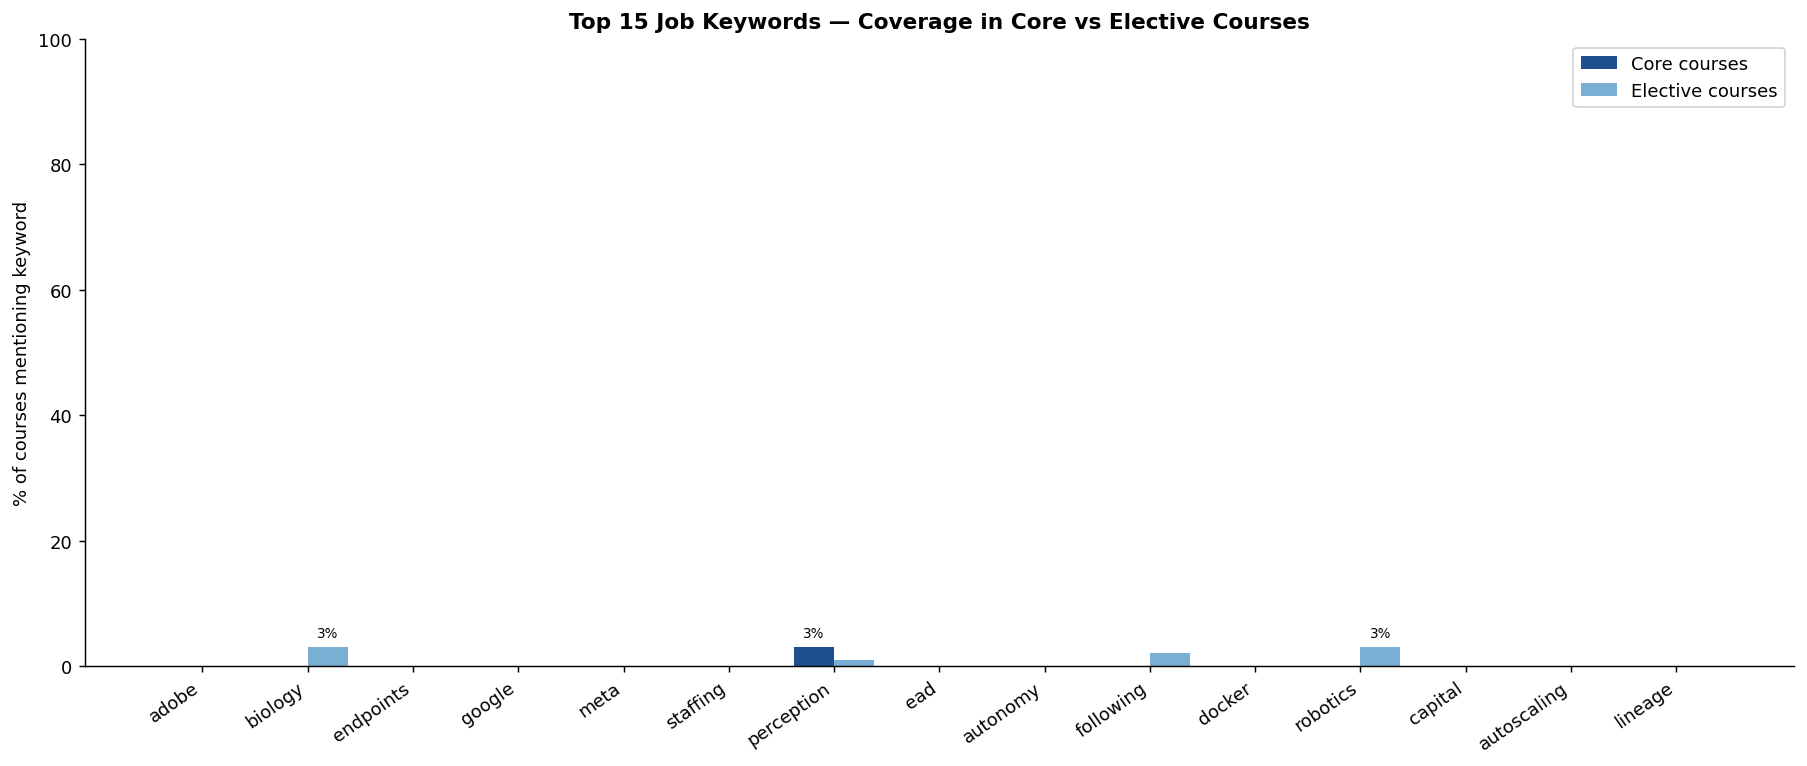

Saved → keyword_demand_heatmap.png


In [18]:
# ── Keyword coverage: Core vs Elective bar comparison ─────────────────────────
# Top 15 global keywords by demand
top15_kw = (kw_df.groupby('keyword')['demand_norm']
            .mean().nlargest(15).index.tolist())

kw_top = kw_df[kw_df['keyword'].isin(top15_kw)].groupby('keyword')[
    ['core_cov', 'elec_cov']
].mean().reindex(top15_kw)

x   = np.arange(len(top15_kw))
w   = 0.38
fig, ax = plt.subplots(figsize=(14, 6))

b1 = ax.bar(x - w/2, kw_top['core_cov'],  w, color='#1F4F8F', label='Core courses')
b2 = ax.bar(x + w/2, kw_top['elec_cov'],  w, color='#7AAED4', label='Elective courses')

ax.set_xticks(x)
ax.set_xticklabels(top15_kw, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('% of courses mentioning keyword')
ax.set_title('Top 15 Job Keywords — Coverage in Core vs Elective Courses',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 100)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('keyword_demand_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → keyword_demand_heatmap.png")


In [19]:
# ── Gap table split by Core / Elective ────────────────────────────────────────
top_gaps = (
    kw_df.sort_values('gap_score', ascending=False)
         .groupby('role').head(8)
         .sort_values(['role', 'gap_score'], ascending=[True, False])
         .reset_index(drop=True)
)

top_gaps[['role', 'keyword', 'core_cov', 'elec_cov', 'demand_norm', 'gap_score']] \
    .rename(columns={
        'role': 'Role', 'keyword': 'Keyword',
        'core_cov': 'Core Coverage %', 'elec_cov': 'Elective Coverage %',
        'demand_norm': 'Demand', 'gap_score': 'Gap Score',
    }) \
    .style \
    .background_gradient(subset=['Gap Score'],        cmap='Reds') \
    .background_gradient(subset=['Core Coverage %'],  cmap='Blues') \
    .background_gradient(subset=['Elective Coverage %'], cmap='Greens') \
    .format({'Core Coverage %': '{:.1f}', 'Elective Coverage %': '{:.1f}',
             'Demand': '{:.2f}', 'Gap Score': '{:.3f}'}) \
    .set_caption('Top Keyword Gaps per Role — with Core vs Elective coverage split')


,Role,Keyword,Core Coverage %,Elective Coverage %,Demand,Gap Score
0,AI Engineer,google,0.0,0.0,1.00,1.000
1,AI Engineer,perception,3.1,1.0,0.99,0.973
2,AI Engineer,autonomy,0.0,0.0,0.91,0.910
3,AI Engineer,following,0.0,2.0,0.91,0.896
4,AI Engineer,docker,0.0,0.0,0.87,0.869
5,AI Engineer,developer,0.0,0.0,0.86,0.863
6,AI Engineer,capital,0.0,0.0,0.86,0.862
7,AI Engineer,robotics,0.0,3.1,0.86,0.844
8,Applied Scientist,biology,0.0,3.1,1.00,0.977
9,Applied Scientist,lab,3.1,1.0,0.82,0.808


## 8  Summary & Insights

In [20]:
print("=" * 72)
print("MSDS CURRICULUM × JOB MARKET — KEY FINDINGS")
print("=" * 72)

for cat in ['Core', 'Elective']:
    sub = courses_df[courses_df['course_category'] == cat]
    print(f"\n{'─'*60}")
    print(f"  {cat.upper()} COURSES  (n={len(sub)})")
    print(f"{'─'*60}")

    print(f"  Top 8 most versatile (highest avg score across roles):")
    for _, r in sub.nlargest(8, 'mean_score').iterrows():
        print(f"    {r['course_code']:<12} {r['source_type']:<16} "
              f"avg={r['mean_score']:.1f}  {r['course_title'][:46]}")

    print(f"\n  Weakly aligned (best score < 30):")
    orphans = sub[sub['best_score'] < 30]
    if orphans.empty:
        print("    None")
    else:
        for _, r in orphans.iterrows():
            print(f"    {r['course_code']:<12} best={r['best_score']:.1f}  {r['course_title'][:50]}")

print("\n" + "=" * 72)
print("  ROLE COVERAGE QUALITY")
print("=" * 72)
for role in role_labels:
    core_top5 = courses_df[courses_df['course_category'] == 'Core'][role].nlargest(5).mean()
    elec_top5 = courses_df[courses_df['course_category'] == 'Elective'][role].nlargest(5).mean()
    print(f"  {role:<32}  core top-5 avg={core_top5:.1f}  elec top-5 avg={elec_top5:.1f}")


MSDS CURRICULUM × JOB MARKET — KEY FINDINGS

────────────────────────────────────────────────────────────
  CORE COURSES  (n=32)
────────────────────────────────────────────────────────────
  Top 8 most versatile (highest avg score across roles):
    CSCI 5612    On-Campus        avg=80.2  Machine Learning for Data Science
    DTSA 5301    Online (DTSA)    avg=63.7  Data Science as a Field
    DTSC 5301    On-Campus        avg=63.7  Data Science as a Field
    DTSA 5304    Online (DTSA)    avg=60.6  Fundamentals of Data Visualization
    CSCI 5502    On-Campus        avg=57.2  Data Mining
    DTSA 5003    Online (DTSA)    avg=52.7  Hypothesis Testing for Data Science
    DTSA 5510    Online (DTSA)    avg=50.6  Unsupervised Algorithms in Machine Learning
    DTSA 5011    Online (DTSA)    avg=49.3  Modern Regression Analysis in R

  Weakly aligned (best score < 30):
    DTSA 5002    best=29.6  Statistical Estimation for Data Science and AI
    DTSA 5501    best=16.6  Algorithms for Searc

In [21]:
# ── Export CSV with category column ──────────────────────────────────────────
export = courses_df[
    ['course_code', 'course_title', 'source_type', 'course_category',
     'program_section', 'specialization']
].copy()
for role in role_labels:
    export[role] = courses_df[role].values.round(1)
export['best_role']  = courses_df['best_role'].values
export['best_score'] = courses_df['best_score'].values.round(1)
export['mean_score'] = courses_df['mean_score'].values.round(1)
export['coverage']   = courses_df['coverage'].values

export.to_csv('msds_compatibility_scores.csv', index=False)
print("Saved → msds_compatibility_scores.csv")
print(f"Shape : {export.shape}")
export.head()


Saved → msds_compatibility_scores.csv
Shape : (130, 16)


,course_code,course_title,source_type,course_category,program_section,specialization,AI Engineer,Applied Scientist,Data Scientist,ML Engineer,MLOps Engineer,Machine Learning Engineer,best_role,best_score,mean_score,coverage
0,DTSA 5001,Probability Foundations for Data Science and AI,Online (DTSA),Core,Section 1 – Statistics Pathway,Data Science Foundations: Statistical Inferenc...,35.7,28.7,34.4,40.8,19.3,33.3,ML Engineer,40.8,32.0,1
1,DTSA 5002,Statistical Estimation for Data Science and AI,Online (DTSA),Core,Section 1 – Statistics Pathway,Data Science Foundations: Statistical Inferenc...,29.1,27.4,29.6,24.8,22.3,29.3,Data Scientist,29.6,27.1,0
2,DTSA 5003,Hypothesis Testing for Data Science,Online (DTSA),Core,Section 1 – Statistics Pathway,Data Science Foundations: Statistical Inferenc...,63.7,48.7,40.3,51.4,49.6,62.5,AI Engineer,63.7,52.7,6
3,DTSA 5011,Modern Regression Analysis in R,Online (DTSA),Core,Section 3 – Core,Statistical Modeling for Data Science Applicat...,44.6,43.7,55.7,48.4,36.5,67.0,Machine Learning Engineer,67.0,49.3,5
4,DTSA 5012,ANOVA and Experimental Design,Online (DTSA),Core,Section 3 – Core,Statistical Modeling for Data Science Applicat...,41.1,58.9,42.1,54.5,44.2,51.0,Applied Scientist,58.9,48.6,6


---
### Colour Key

| Colour | Meaning |
|--------|---------|
| Deep gold | Online DTSA — Core (Sections 1–3) |
| Light gold | Online DTSA — Elective (Section 4) |
| Deep blue | On-Campus — Core (Sections 1–3) |
| Light blue | On-Campus — Elective (Section 4) |

### Score Interpretation

| Score | Meaning |
|-------|---------|
| 70–100 | Very strong alignment |
| 40–69 | Good overlap |
| 20–39 | Partial overlap |
| 0–19 | Weak / foundational |

Scores are TF-IDF cosine similarity, min-max normalised per role (0–100).
